In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

class racetrack_map:
    def __init__(self):
        # 32×16 grid
        self.grid = np.zeros((32, 16))
        self.rows, self.cols = self.grid.shape

    def create_track_map(self):
        # add track upper part
        for row in range(0, 6):
            for col in range(3, self.cols):
                self.grid[row, col] = 1
        for row in range(1, 3):
            for col in range(2, self.cols):
                self.grid[row, col] = 1
        for row in range(3, 4):
            for col in range(1, self.cols):
                self.grid[row, col] = 1
        for row in range(4, 6):
            for col in range(0, self.cols):
                self.grid[row, col] = 1
        for row in range(6, 7):
            for col in range(0, 11):
                self.grid[row, col] = 1

        # middle part
        for row in range(7, 14):
            for col in range(0, 10):
                self.grid[row, col] = 1
        for row in range(14, 23):
            for col in range(1, 10):
                self.grid[row, col] = 1

        # add track lower part
        for row in range(23, 30):
            for col in range(2, 10):
                self.grid[row, col] = 1
        for row in range(30, 32):
            for col in range(4, 10):
                self.grid[row, col] = 1

        # add start line at row=31
        for col in range(4, 10):
            self.grid[31, col] = 2

        # add finish line at row=0..5, col=15
        for row in range(0, 6):
            self.grid[row, 15] = 3

        return self.grid

    def visualize_track(self, trajectories=None):
        cmap = mcolors.ListedColormap(['white', 'lightgray', 'salmon', 'lightgreen'])
        plt.figure(figsize=(4, 8))
        plt.imshow(self.grid, cmap=cmap, origin='upper')

        for i in range(self.rows):
            plt.axhline(i - 0.5, color='black', linewidth=0.5)
        for j in range(self.cols):
            plt.axvline(j - 0.5, color='black', linewidth=0.5)

        if trajectories:
            for trajectory in trajectories:
                ys = [s[0] for s in trajectory]
                xs = [s[1] for s in trajectory]
                plt.plot(xs, ys, 'ro-', markersize=2, linewidth=1.0, alpha=0.7)
                plt.plot(xs[0], ys[0], 'bo', markersize=5)  # start
                plt.plot(xs[-1], ys[-1], 'go', markersize=5)  # end

        plt.axis('off')
        plt.tight_layout()
        plt.show()

class RacetrackEnv:
    """
    crash_mode=0 => mild_crash()
    crash_mode=1 => harsh_crash()
    """
    def __init__(self, track_map, crash_mode=0, noise=0.1):
        self.grid = track_map.grid
        self.rows, self.cols = self.grid.shape

        self.crash_mode = crash_mode
        self.noise = noise

        self.starting_cells = [(r, c) for r in range(self.rows)
                               for c in range(self.cols) if self.grid[r, c] == 2]
        self.terminal_cells = [(r, c) for r in range(self.rows)
                               for c in range(self.cols) if self.grid[r, c] == 3]

        self.state = None  

    def reset(self):
        start_cell = random.choice(self.starting_cells)
        self.state = (start_cell[0], start_cell[1], 0, 0)
        return self.state

    def mild_crash(self):
        row, col, _, _ = self.state
        best_r, best_c = self.nearest_track_cell(row, col)
        self.state = (best_r, best_c, 0, 0)

    def harsh_crash(self):
        # 严重撞击 => 回到随机起点, 速度=0
        start = random.choice(self.starting_cells)
        self.state = (start[0], start[1], 0, 0)

    def nearest_track_cell(self, row, col):
        # 暴力搜索离 (row,col) 最近的“赛道=1”格子
        best = (row, col)
        min_dist = float('inf')
        for r in range(self.rows):
            for c in range(self.cols):
                if self.grid[r, c] == 1:
                    dist = (r - row)**2 + (c - col)**2
                    if dist < min_dist:
                        min_dist = dist
                        best = (r, c)
        return best

    def step(self, action):
        row, col, v_r, v_c = self.state
        ar, ac = action

        # 1. 有噪声 => 动作为 (0,0)
        if random.random() < self.noise:
            ar, ac = 0, 0

        # 2. 更新速度
        new_vr = v_r + ar
        new_vc = v_c + ac
        # clamp: 行速度 -4 <= vr <= 0, 列速度 0 <= vc <= 4
        new_vr = max(-4, min(0, new_vr))
        new_vc = max(0, min(4, new_vc))

        # 3. 更新位置
        n_row = row + new_vr
        n_col = col + new_vc

        # 4. 检测终点
        if (n_row, n_col) in self.terminal_cells:
            self.state = (n_row, n_col, new_vr, new_vc)
            return self.state, True, False  # done=True

        # 5. 撞墙或越界 => crash
        if not (0 <= n_row < self.rows and 0 <= n_col < self.cols) or self.grid[n_row, n_col] == 0:
            if self.crash_mode == 0:
                self.mild_crash()
            else:
                self.harsh_crash()
            return self.state, False, True

        # 6. 防止速度=0,0 后卡死 (非起点), 强制给一点速度
        if new_vr == 0 and new_vc == 0 and self.grid[row, col] != 2:
            # 随机给一点上或右的速度
            new_vr, new_vc = random.choice([(-1, 0), (0, 1)])
            # 重新计算位置
            new_vr = max(-4, min(0, new_vr))
            new_vc = max(0, min(4, new_vc))
            n_row = row + new_vr
            n_col = col + new_vc

        self.state = (n_row, n_col, new_vr, new_vc)
        return self.state, False, False

# ============ 3. race() 函数 ============
def race(env, policy=None, max_steps=500):
    trajectory = []
    total_reward = 0

    s = env.reset()
    for _ in range(max_steps):
        trajectory.append(s)
        if policy and s in policy:
            a = policy[s]
        else:
            # 动作只选 ar<=0, ac>=0
            acts = []
            for ar in [-1, 0, 1]:
                for ac in [-1, 0, 1]:
                    if ar <= 0 and ac >= 0:
                        acts.append((ar, ac))
            a = random.choice(acts)

        s_next, done, _ = env.step(a)
        total_reward -= 1
        s = s_next
        if done:
            trajectory.append(s)
            break

    return trajectory, total_reward

# ============ 4. MC 相关函数 ============
def first_visit_mc_prediction(env, policy, num_episodes=2000, gamma=0.9):
    V = defaultdict(float)
    returns_count = defaultdict(int)

    for _ in range(num_episodes):
        traj, _ = race(env, policy)
        G = 0
        visited = set()
        for t in reversed(range(len(traj))):
            s = traj[t]
            G = gamma * G - 1
            if s not in visited:
                visited.add(s)
                returns_count[s] += 1
                V[s] += (G - V[s]) / returns_count[s]
    return V

def mc_on_policy_control(env, num_episodes=2000, gamma=0.9, epsilon=0.1):
    Q = defaultdict(lambda: defaultdict(float))
    returns_count = defaultdict(lambda: defaultdict(int))
    policy = {}

    def possible_actions():
        # ar <= 0, ac >= 0
        acts = []
        for ar in [-1, 0, 1]:
            for ac in [-1, 0, 1]:
                if ar <= 0 and ac >= 0:
                    acts.append((ar, ac))
        return acts

    def epsilon_greedy(state):
        acts = possible_actions()
        if state not in policy:
            policy[state] = random.choice(acts)

        if random.random() < epsilon:
            return random.choice(acts)
        else:
            return policy[state]

    for _ in range(num_episodes):
        episode_states = []
        episode_actions = []
        episode_rewards = []

        s = env.reset()
        for _2 in range(1000):
            a = epsilon_greedy(s)
            episode_states.append(s)
            episode_actions.append(a)
            s_next, done, _ = env.step(a)
            episode_rewards.append(-1)  # 每步 -1
            s = s_next
            if done:
                break

        G = 0
        visited_sa = set()
        for t in reversed(range(len(episode_states))):
            st = episode_states[t]
            at = episode_actions[t]
            rt = episode_rewards[t]
            G = gamma * G + rt
            if (st, at) not in visited_sa:
                visited_sa.add((st, at))
                returns_count[st][at] += 1
                Q[st][at] += (G - Q[st][at]) / returns_count[st][at]

                best_a = max(Q[st], key=Q[st].get)
                policy[st] = best_a

    return policy, Q

def mc_off_policy_control(env, num_episodes=2000, gamma=0.9):
    Q = defaultdict(lambda: defaultdict(float))
    C = defaultdict(lambda: defaultdict(float))
    target_policy = {}

    # 行为策略：随机 (ar<=0, ac>=0)
    def behavior_policy(_s):
        acts = []
        for ar in [-1, 0, 1]:
            for ac in [-1, 0, 1]:
                if ar <= 0 and ac >= 0:
                    acts.append((ar, ac))
        return random.choice(acts)

    for _ in range(num_episodes):
        episode_states = []
        episode_actions = []
        episode_rewards = []

        s = env.reset()
        for _2 in range(1000):
            a = behavior_policy(s)
            episode_states.append(s)
            episode_actions.append(a)
            s_next, done, _ = env.step(a)
            episode_rewards.append(-1)
            s = s_next
            if done:
                break

        G = 0
        W = 1.0
        visited_sa = set()
        for t in reversed(range(len(episode_states))):
            st = episode_states[t]
            at = episode_actions[t]
            rt = episode_rewards[t]
            G = gamma * G + rt

            if (st, at) not in visited_sa:
                visited_sa.add((st, at))
                C[st][at] += W
                Q[st][at] += (W / C[st][at]) * (G - Q[st][at])

                # 贪心选动作
                best_a = max(Q[st], key=Q[st].get)
                target_policy[st] = best_a

                if at != best_a:
                    break

            # 行为策略9种动作，概率1/9
            W *= 1 / (1/9)

    return target_policy, Q

# def dictQ_to_arrayV(Q_dict):
#     """
#     将 Q(state)[action] 形式的字典映射到一个 (32,16) 的状态价值数组，
#     忽略速度，只取同一 (row,col) 下速度维度的最大 Q。
#     """
#     V_array = np.zeros((32,16))
#     for (row, col, v_r, v_c), actions_q in Q_dict.items():
#         if len(actions_q) == 0:
#             continue
#         max_q_this_state = max(actions_q.values())
#         if max_q_this_state > V_array[row, col]:
#             V_array[row, col] = max_q_this_state
#     return V_array

# def value_diff(q_values_list, vi_result):
#     """
#     q_values_list: [Q_on, Q_off, ...] 各种 Q 字典
#     vi_result: { "v": shape=(32,16), ...}
#     """
#     diffs = []
#     for Q_dict in q_values_list:
#         # 转成 (32,16) 数组
#         V_array = dictQ_to_arrayV(Q_dict)
#         # 与最优值函数做差
#         diff = np.abs(V_array - vi_result["v"])
#         diffs.append(np.mean(diff))
#     return diffs

# def n_optimal_actions(q_values, vi_result):
#     n_optimal = []
#     optimal_actions = np.argmax(vi_result["q"], axis=-1)
#     for q in q_values:
#         greedy_actions = np.argmax(q, axis=-1)
#         n_optimal.append(np.sum(greedy_actions == optimal_actions))
#     return n_optimal

# ============ 5. 主函数测试 ============

    
 









1) MC Prediction...
   len(V) = 1360
2) On-Policy MC Control...
   on_policy size = 1200
3) Off-Policy MC Control...
   off_policy size = 368
Testing on_policy:
   Steps=14, Reward=-13, FinalPos=(2, 15, -1, 2)
Testing off_policy:
   Steps=20, Reward=-19, FinalPos=(1, 15, 0, 2)


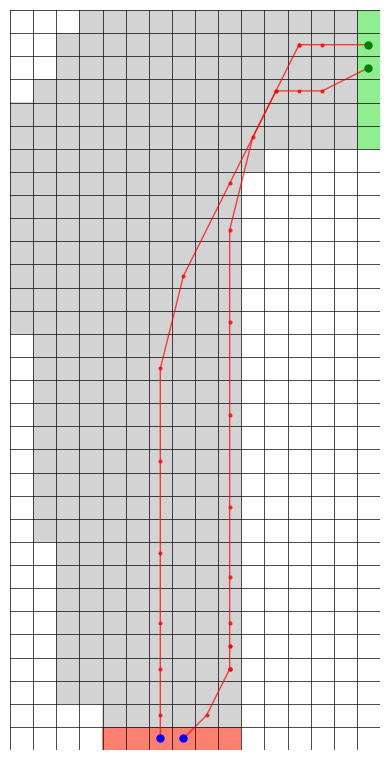

In [2]:
if __name__ == "__main__":
    track_map = racetrack_map()
    track_map.create_track_map()

    # crash_mode=0 => mild_crash, noise=0.1 => 10% 概率动作被置0
    env = RacetrackEnv(track_map, crash_mode=0, noise=0.1)

    print("1) MC Prediction...")
    V = first_visit_mc_prediction(env, policy={}, num_episodes=10000)
    print("   len(V) =", len(V))

    print("2) On-Policy MC Control...")
    on_policy, Q_on = mc_on_policy_control(env, num_episodes=10000)
    print("   on_policy size =", len(on_policy))

    print("3) Off-Policy MC Control...")
    off_policy, Q_off = mc_off_policy_control(env, num_episodes=10000)
    print("   off_policy size =", len(off_policy))

    # 测试
    print("Testing on_policy:")
    traj_on, r_on = race(env, on_policy, max_steps=5000)
    print(f"   Steps={len(traj_on)}, Reward={r_on}, FinalPos={traj_on[-1]}")

    print("Testing off_policy:")
    traj_off, r_off = race(env, off_policy, max_steps=5000)
    print(f"   Steps={len(traj_off)}, Reward={r_off}, FinalPos={traj_off[-1]}")

    # 可视化
    track_map.visualize_track([traj_on, traj_off])

Training On-Policy MC Control...
Done, policy size = 916
Trajectory 1: steps=12, reward=-11
Trajectory 2: steps=12, reward=-11
Trajectory 3: steps=14, reward=-13
Trajectory 4: steps=14, reward=-13
Trajectory 5: steps=14, reward=-13


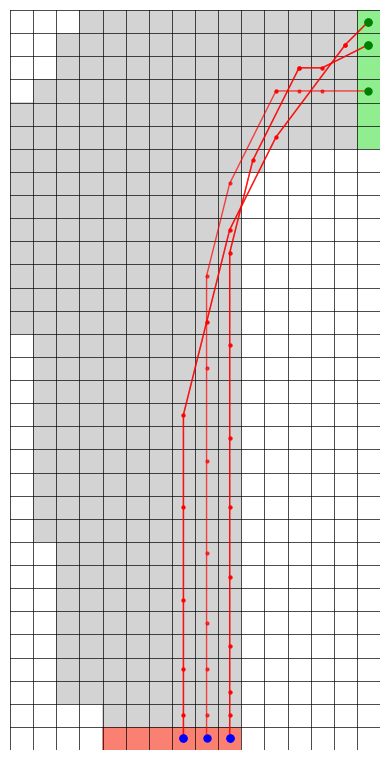

In [3]:
if __name__ == "__main__":
    # 1. 构造赛道 + 环境
    rt_map = racetrack_map()
    rt_map.create_track_map()
    env = RacetrackEnv(rt_map, crash_mode=0, noise=0.1)

    # 2. 用 Monte Carlo 控制训练，得到最优策略
    print("Training On-Policy MC Control...")
    on_policy, Q_on = mc_on_policy_control(env, num_episodes=5000)
    print("Done, policy size =", len(on_policy))

    # 3. 关闭噪声，采样多条轨迹
    env.noise = 0.0
    trajectories = []
    for i in range(5):
        traj, total_reward = race(env, on_policy, max_steps=1000)
        trajectories.append(traj)
        print(f"Trajectory {i+1}: steps={len(traj)}, reward={total_reward}")

    # 4. 可视化这些轨迹
    rt_map.visualize_track(trajectories)
    


In [4]:
print(trajectories)

[[(31, 7, 0, 0), (30, 7, -1, 0), (28, 7, -2, 0), (25, 7, -3, 0), (21, 7, -4, 0), (17, 7, -4, 0), (13, 8, -4, 1), (9, 9, -4, 1), (5, 11, -4, 2), (1, 14, -4, 3), (1, 14, 0, 0), (0, 15, -1, 1)], [(31, 7, 0, 0), (30, 7, -1, 0), (28, 7, -2, 0), (25, 7, -3, 0), (21, 7, -4, 0), (17, 7, -4, 0), (13, 8, -4, 1), (9, 9, -4, 1), (5, 11, -4, 2), (1, 14, -4, 3), (1, 14, 0, 0), (0, 15, -1, 1)], [(31, 8, 0, 0), (30, 8, -1, 0), (28, 8, -2, 0), (26, 8, -2, 0), (23, 8, -3, 0), (19, 8, -4, 0), (15, 8, -4, 0), (11, 8, -4, 0), (7, 9, -4, 1), (3, 11, -4, 2), (3, 11, 0, 0), (3, 12, 0, 1), (3, 13, 0, 1), (3, 15, 0, 2)], [(31, 9, 0, 0), (30, 9, 0, 0), (29, 9, -1, 0), (27, 9, -2, 0), (24, 9, -3, 0), (21, 9, -3, 0), (18, 9, -3, 0), (14, 9, -4, 0), (10, 9, -4, 0), (6, 10, -4, 1), (2, 12, -4, 2), (2, 12, 0, 0), (2, 13, 0, 1), (1, 15, -1, 2)], [(31, 9, 0, 0), (30, 9, 0, 0), (29, 9, -1, 0), (27, 9, -2, 0), (24, 9, -3, 0), (21, 9, -3, 0), (18, 9, -3, 0), (14, 9, -4, 0), (10, 9, -4, 0), (6, 10, -4, 1), (2, 12, -4, 2), 